In [1]:

!pip install scanpy

import scanpy as sc
import pandas as pd
import numpy as np

print("=== Downloading and Loading PBMC 3k Dataset ===")

adata = sc.datasets.pbmc3k_processed()

print("\n=== Data Loaded Successfully ===")
print(f"Data matrix shape (cells x genes): {adata.shape}")
print("\n=== Cell Annotations (adata.obs) ===")
print(adata.obs.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 4.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.7 MB/s eta 0:00:0000:01:00:01
  Attempting uninstall: umap-learn
    Found existing installation: umap-learn 0.5.11
    Uninstalling umap-learn-0.5.11:
      Successfully uninstalled umap-learn-0.5.11
=== Downloading and Loading PBMC 3k Dataset ===


  0%|          | 0.00/23.5M [00:00<?, ?B/s]


=== Data Loaded Successfully ===
Data matrix shape (cells x genes): (2638, 1838)

=== Cell Annotations (adata.obs) ===
                  n_genes  percent_mito  n_counts          louvain
index                                                             
AAACATACAACCAC-1      781      0.030178    2419.0      CD4 T cells
AAACATTGAGCTAC-1     1352      0.037936    4903.0          B cells
AAACATTGATCAGC-1     1131      0.008897    3147.0      CD4 T cells
AAACCGTGCTTCCG-1      960      0.017431    2639.0  CD14+ Monocytes
AAACCGTGTATGCG-1      522      0.012245     980.0         NK cells


In [2]:
from sklearn.preprocessing import LabelEncoder

print("=== Extracting Features and Labels ===")

# Extract feature matrix X (gene expression counts)
if hasattr(adata.raw.X, 'toarray'):
    X_raw = adata.raw.X.toarray()
else:
    X_raw = adata.raw.X

# Extract target labels y (cell types from Louvain clustering)
y_labels = adata.obs['louvain'].values

# Encode string labels to integer classes for machine learning models
encoder = LabelEncoder()
y = encoder.fit_transform(y_labels)

print(f"Shape of X matrix: {X_raw.shape}")
print(f"Shape of y labels: {y.shape}")
print(f"Total number of unique cell types: {len(np.unique(y))}")
print(f"Cell type classes: {encoder.classes_}")

=== Extracting Features and Labels ===
Shape of X matrix: (2638, 13714)
Shape of y labels: (2638,)
Total number of unique cell types: 8
Cell type classes: ['B cells' 'CD14+ Monocytes' 'CD4 T cells' 'CD8 T cells' 'Dendritic cells'
 'FCGR3A+ Monocytes' 'Megakaryocytes' 'NK cells']


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# Assuming X_raw and y are already defined from the previous Scanpy steps

print("=== Starting Preprocessing Experiment ===")

# 1. Raw Data
X_raw_data = X_raw.copy()

# 2. Log-Transformed Data (log(x + 1) to handle the extreme sparsity and zeros)
X_log_data = np.log1p(X_raw)

# 3. Binarized Data (1 if gene is expressed, 0 if not)
X_bin_data = (X_raw > 0).astype(float)

# Dictionary to store datasets for iteration
datasets = {
    "Raw Counts": X_raw_data,
    "Log-Transformed": X_log_data,
    "Binarized": X_bin_data
}

print("Data transformations completed successfully.")
print("-" * 50)

# Run Logistic Regression for each preprocessing method
for name, X_data in datasets.items():
    # Split the data, preserving the proportion of cell types (stratify=y)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Initialize the linear model with a strong regularization baseline
    clf = LogisticRegression(max_iter=1000, random_state=42)
    
    start_time = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Evaluate accuracy
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    print(f"Dataset Pipeline : {name}")
    print(f"Train Accuracy   : {train_acc:.4f}")
    print(f"Test Accuracy    : {test_acc:.4f}")
    print(f"Training Time    : {train_time:.2f} seconds")
    print("-" * 50)

=== Starting Preprocessing Experiment ===
Data transformations completed successfully.
--------------------------------------------------
Dataset Pipeline : Raw Counts
Train Accuracy   : 1.0000
Test Accuracy    : 0.9280
Training Time    : 9.83 seconds
--------------------------------------------------
Dataset Pipeline : Log-Transformed
Train Accuracy   : 1.0000
Test Accuracy    : 0.9223
Training Time    : 8.96 seconds
--------------------------------------------------
Dataset Pipeline : Binarized
Train Accuracy   : 1.0000
Test Accuracy    : 0.9205
Training Time    : 3.62 seconds
--------------------------------------------------


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Assuming X_raw, y are already in memory

print("=== Starting 2x2 Experimental Design ===")

# Create datasets
datasets = {
    "Log-Transformed (Standard)": np.log1p(X_raw),
    "Binarized (Minimalist)": (X_raw > 0).astype(float)
}

# Define models to compare
models = {
    "Simple (Logistic Regression)": LogisticRegression(max_iter=1000, random_state=42),
    "Complex (Random Forest)": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for data_name, X_data in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y, test_size=0.2, random_state=42, stratify=y
    )
    
    for model_name, clf in models.items():
        print(f"Testing Pipeline: [Data: {data_name}] + [Model: {model_name}]")
        
        start_time = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        test_acc = accuracy_score(y_test, clf.predict(X_test))
        
        print(f"Test Accuracy : {test_acc:.4f}")
        print(f"Training Time : {train_time:.2f} sec")
        print("-" * 50)
        
        results.append({
            "Data": data_name,
            "Model": model_name,
            "Test Accuracy": test_acc,
            "Time (s)": train_time
        })

print("=== Experiment Finished ===")

=== Starting 2x2 Experimental Design ===
Testing Pipeline: [Data: Log-Transformed (Standard)] + [Model: Simple (Logistic Regression)]
Test Accuracy : 0.9223
Training Time : 8.37 sec
--------------------------------------------------
Testing Pipeline: [Data: Log-Transformed (Standard)] + [Model: Complex (Random Forest)]
Test Accuracy : 0.9053
Training Time : 2.93 sec
--------------------------------------------------
Testing Pipeline: [Data: Binarized (Minimalist)] + [Model: Simple (Logistic Regression)]
Test Accuracy : 0.9205
Training Time : 5.14 sec
--------------------------------------------------
Testing Pipeline: [Data: Binarized (Minimalist)] + [Model: Complex (Random Forest)]
Test Accuracy : 0.8674
Training Time : 2.92 sec
--------------------------------------------------
=== Experiment Finished ===


=== Part 1: Re-training the Champion Model ===
=== Part 2: Extracting Biological Marker Genes ===
Top 5 defining genes for B cells based on Minimalist Model:
  1. CD79A (Weight: 0.3350)
  2. MS4A1 (Weight: 0.3072)
  3. HLA-DQA1 (Weight: 0.2756)
  4. HLA-DQB1 (Weight: 0.2557)
  5. CD79B (Weight: 0.2471)

=== Part 3: Generating Fancy Visualizations ===
Running PCA for visualization...


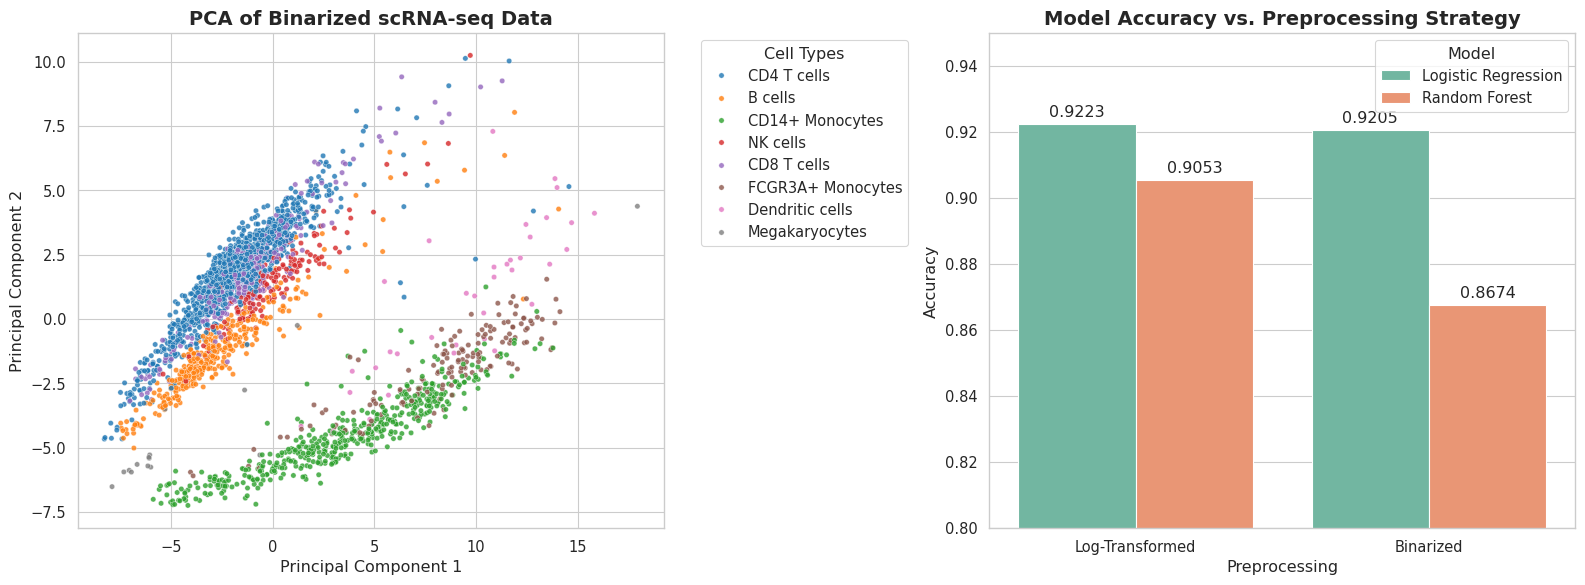

=== All visualizations generated successfully ===


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

print("=== Part 1: Re-training the Champion Model ===")

X_bin = (X_raw > 0).astype(float)
X_train_bin, X_test_bin, y_train, y_test = train_test_split(
    X_bin, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train Logistic Regression on Binarized Data
clf_best = LogisticRegression(max_iter=1000, random_state=42)
clf_best.fit(X_train_bin, y_train)

print("=== Part 2: Extracting Biological Marker Genes ===")

gene_names = adata.raw.var_names.values

class_idx = 0 
class_name = encoder.classes_[class_idx]
weights = clf_best.coef_[class_idx]

top5_indices = np.argsort(weights)[-5:][::-1]
top5_genes = gene_names[top5_indices]

print(f"Top 5 defining genes for {class_name} based on Minimalist Model:")
for i, gene in enumerate(top5_genes):
    print(f"  {i+1}. {gene} (Weight: {weights[top5_indices[i]]:.4f})")

print("\n=== Part 3: Generating Fancy Visualizations ===")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print("Running PCA for visualization...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_bin)

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=encoder.inverse_transform(y), 
    palette="tab10", s=15, alpha=0.8, ax=axes[0]
)
axes[0].set_title("PCA of Binarized scRNA-seq Data", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cell Types")

plot_data = pd.DataFrame({
    'Preprocessing': ['Log-Transformed', 'Log-Transformed', 'Binarized', 'Binarized'],
    'Model': ['Logistic Regression', 'Random Forest', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [0.9223, 0.9053, 0.9205, 0.8674]
})

sns.barplot(
    data=plot_data, x='Preprocessing', y='Accuracy', 
    hue='Model', palette="Set2", ax=axes[1]
)
axes[1].set_title("Model Accuracy vs. Preprocessing Strategy", fontsize=14, fontweight='bold')
axes[1].set_ylim(0.80, 0.95)
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

print("=== All visualizations generated successfully ===")

=== Starting Advanced Visualization Pipeline ===
Calculating global feature importance...
Analyzing data sparsity...


/tmp/ipykernel_55/1242143527.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Weight', y='Cell Type', palette='viridis', ax=ax_imp)
/tmp/ipykernel_55/1242143527.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='Cell Type', y='Expression', inner="quartile", palette="Set3", ax=ax_vio)
/tmp/ipykernel_55/1242143527.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_vio.set_xticklabels(ax_vio.get_xticklabels(), rotation=45)


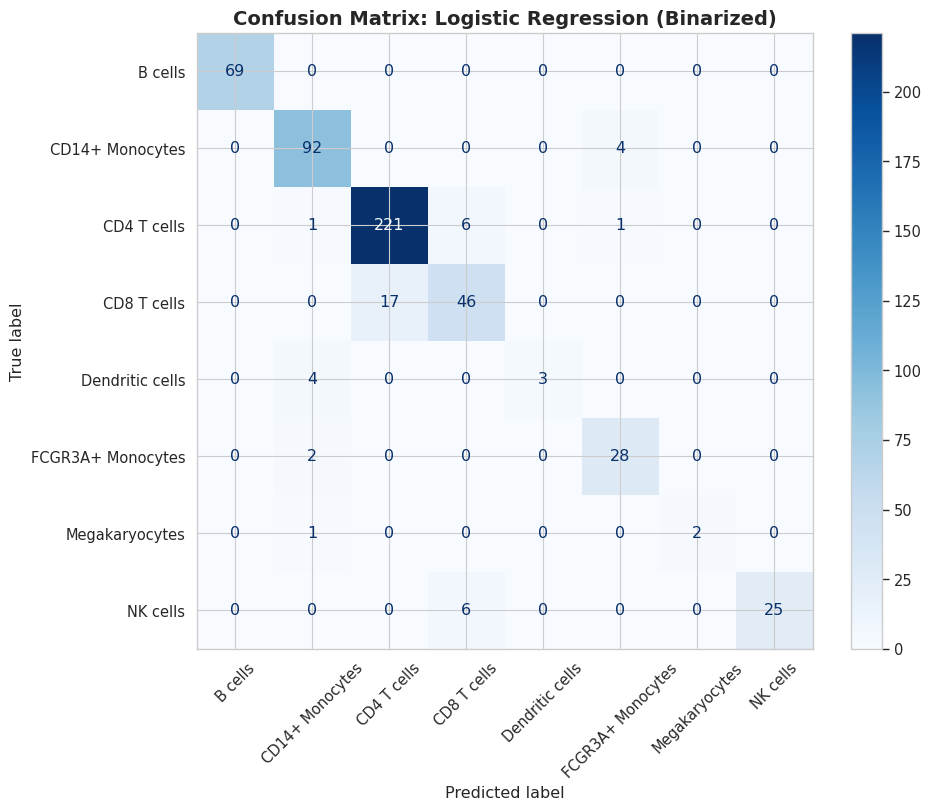

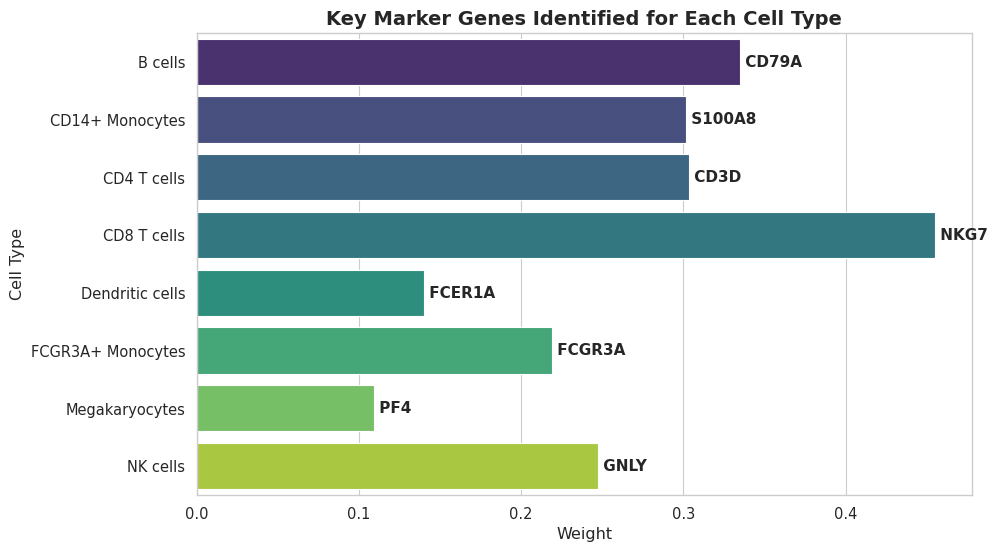

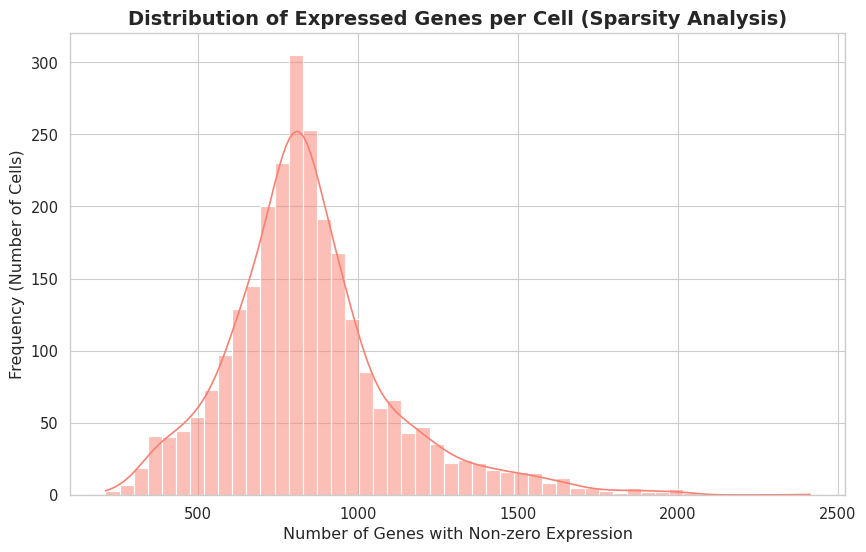

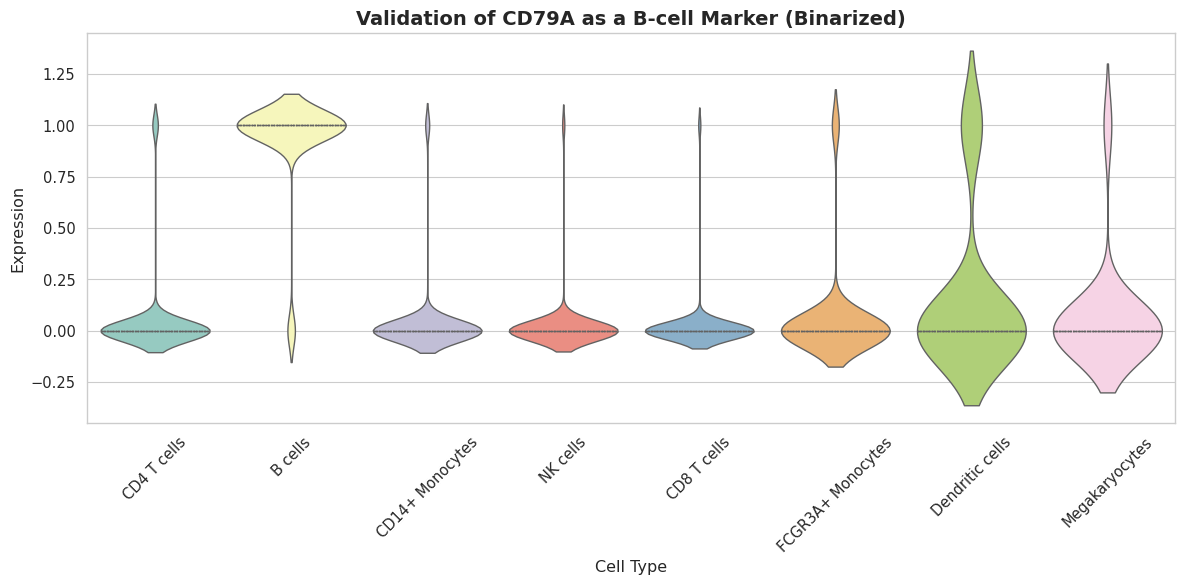

=== Advanced Visualizations Complete ===


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

print("=== Starting Advanced Visualization Pipeline ===")

# 1. Generate Confusion Matrix for the Champion Model (Logistic Regression on Binarized Data)
y_pred = clf_best.predict(X_test_bin)
cm = confusion_matrix(y_test, y_pred)
fig_cm, ax_cm = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues', ax=ax_cm, xticks_rotation=45)
ax_cm.set_title("Confusion Matrix: Logistic Regression (Binarized)", fontsize=14, fontweight='bold')

# 2. Global Feature Importance (Top Genes for ALL Cell Types)
print("Calculating global feature importance...")
all_top_genes = []
for i, class_label in enumerate(encoder.classes_):
    weights = clf_best.coef_[i]
    top_idx = np.argmax(weights)
    all_top_genes.append({
        'Cell Type': class_label,
        'Top Gene': gene_names[top_idx],
        'Weight': weights[top_idx]
    })

df_importance = pd.DataFrame(all_top_genes)
fig_imp, ax_imp = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_importance, x='Weight', y='Cell Type', palette='viridis', ax=ax_imp)
# Add gene names as annotations on the bars
for i, p in enumerate(ax_imp.patches):
    ax_imp.annotate(f" {df_importance.iloc[i]['Top Gene']}", 
                   (p.get_width(), p.get_y() + p.get_height()/2.),
                   ha='left', va='center', fontsize=11, fontweight='bold')
ax_imp.set_title("Key Marker Genes Identified for Each Cell Type", fontsize=14, fontweight='bold')

# 3. Data Sparsity Visualization (The 'Why Binarization' Argument)
print("Analyzing data sparsity...")
non_zero_counts = np.sum(X_raw > 0, axis=1)
fig_dist, ax_dist = plt.subplots(figsize=(10, 6))
sns.histplot(non_zero_counts, bins=50, kde=True, color='salmon', ax=ax_dist)
ax_dist.set_title("Distribution of Expressed Genes per Cell (Sparsity Analysis)", fontsize=14, fontweight='bold')
ax_dist.set_xlabel("Number of Genes with Non-zero Expression")
ax_dist.set_ylabel("Frequency (Number of Cells)")

# 4. Marker Gene Validation (Violin Plot for CD79A)
# We pick CD79A (index for B cells) to show its expression pattern
target_gene = "CD79A"
gene_idx = np.where(gene_names == target_gene)[0][0]
gene_expression = X_bin[:, gene_idx]

df_violin = pd.DataFrame({
    'Expression': gene_expression,
    'Cell Type': encoder.inverse_transform(y)
})

fig_vio, ax_vio = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_violin, x='Cell Type', y='Expression', inner="quartile", palette="Set3", ax=ax_vio)
ax_vio.set_title(f"Validation of {target_gene} as a B-cell Marker (Binarized)", fontsize=14, fontweight='bold')
ax_vio.set_xticklabels(ax_vio.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("=== Advanced Visualizations Complete ===")